In [19]:

import pandas as pd

hisse_df = pd.read_csv("thyao_veri.csv", index_col=0, parse_dates=True)
print(hisse_df.tail())

                  Open        High         Low       Close    Volume
2024-12-25  282.319516  283.052179  281.098411  281.586853  12283659
2024-12-26  282.807975  286.471291  281.342649  283.296417  27141490
2024-12-27  283.540641  286.471294  283.052199  284.029083  23638402
2024-12-30  284.517544  284.761765  275.725586  275.725586  20734285
2024-12-31  275.969782  279.144655  272.306466  274.504456  26585935


In [20]:

# ── GENEL BİLGİ & İSTATİSTİKLER ────────────────────────────────────────────
print(f"Boyut        : {hisse_df.shape[0]:,} gün  x  {hisse_df.shape[1]} sütun")
print(f"Tarih aralığı: {hisse_df.index[0]}  →  {hisse_df.index[-1]}")
print(f"Eksik değer  : {hisse_df.isnull().sum().sum()}\n")
print("─" * 45)
print(hisse_df.info())


Boyut        : 3,858 gün  x  5 sütun
Tarih aralığı: 2010-01-01 00:00:00  →  2024-12-31 00:00:00
Eksik değer  : 0

─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3858 entries, 2010-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3858 non-null   float64
 1   High    3858 non-null   float64
 2   Low     3858 non-null   float64
 3   Close   3858 non-null   float64
 4   Volume  3858 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 180.8 KB
None


## Görev 1 — Türetilmiş Özellik Mühendisliği (MA5, RSI, Günlük Getiri)

In [21]:
# hisse_df'yi bozmadan kopyasını alıyoruz
model_df = hisse_df.copy()

# ── 1) MA5: Son 5 günün kapanış ortalaması (kısa vadeli trend) ──────────────
model_df['MA5'] = model_df['Close'].rolling(window=5).mean()

# ── 2) RSI (14 günlük) ──────────────────────────────────────────────────────
delta = model_df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
model_df['RSI'] = 100 - (100 / (1 + gain / loss))

# ── 3) Günlük Getiri (%) ────────────────────────────────────────────────────
model_df['Daily_Return'] = model_df['Close'].pct_change() * 100

print(f"Orijinal sütunlar : {list(hisse_df.columns)}")
print(f"Yeni sütunlar     : {list(model_df.columns)}")
print(f"Toplam feature    : {model_df.shape[1]}")
model_df.head(20)


Orijinal sütunlar : ['Open', 'High', 'Low', 'Close', 'Volume']
Yeni sütunlar     : ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'RSI', 'Daily_Return']
Toplam feature    : 8


,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return
2010-01-01,3.442062,3.442062,3.442062,3.442062,0,NaN,NaN,NaN
2010-01-04,3.472522,3.533444,3.350680,3.502983,11846086,NaN,NaN,1.769904
2010-01-05,3.502983,3.533444,3.472522,3.502983,7929532,NaN,NaN,0.000000
2010-01-06,3.502983,3.533444,3.411601,3.472522,9721300,NaN,NaN,-0.869575
2010-01-07,3.411601,3.442062,3.381140,3.411601,7407485,3.466430,NaN,-1.754379
2010-01-08,3.411601,3.442062,3.350680,3.350680,8583119,3.448154,NaN,-1.785693
2010-01-11,3.381140,3.411601,3.259297,3.350680,10830225,3.417693,NaN,0.000000
2010-01-12,3.320219,3.350680,3.228837,3.289758,10073647,3.375048,NaN,-1.818209
2010-01-13,3.289758,3.411601,3.259297,3.411601,13076455,3.362864,NaN,3.703710
2010-01-14,3.472522,3.533444,3.411601,3.472522,20038297,3.375048,NaN,1.785707


In [22]:
#Check if there is any null value in the dataset
model_df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
MA5              4
RSI             14
Daily_Return     1
dtype: int64

## Görev 2 — Hedef (Target) Değişkeni Oluşturma

**Hedef:** Yarınki kapanış bugünkünden yüksek mi?
- `1` → Yükseliş (Yukarı)
- `0` → Düşüş / Yatay (Aşağı)

Hedef Değişken Dağılımı:
  Düşüş    (0): 2,000 gün  (51.9%)
  Yükseliş (1): 1,857 gün  (48.1%)


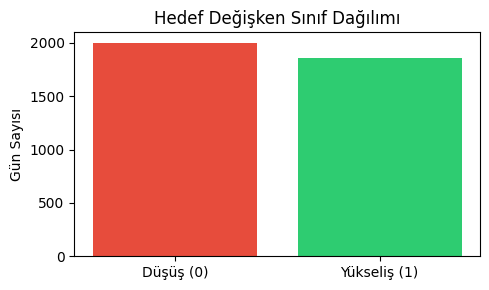

In [23]:
# shift(-1): yarınki kapanışı bugünün satırına getirir
# Eğer yarınki kapanış > bugünkü kapanış → 1, değilse → 0
import matplotlib.pyplot as plt

model_df['Target'] = (model_df['Close'].shift(-1) > model_df['Close']).astype(int)

# Son satırda yarınki veri yok → çıkar
model_df = model_df.iloc[:-1]

counts = model_df['Target'].value_counts()
print("Hedef Değişken Dağılımı:")
print(f"  Düşüş    (0): {counts[0]:,} gün  ({counts[0]/len(model_df)*100:.1f}%)")
print(f"  Yükseliş (1): {counts[1]:,} gün  ({counts[1]/len(model_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Düşüş (0)', 'Yükseliş (1)'], [counts[0], counts[1]],
       color=['#e74c3c', '#2ecc71'])
ax.set_title('Hedef Değişken Sınıf Dağılımı')
ax.set_ylabel('Gün Sayısı')
plt.tight_layout()
plt.show()

In [24]:
model_df['Target'].isnull().sum()  

model_df.tail()

,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return,Target
2024-12-24,279.388863,280.609968,276.702432,278.900421,15485512,281.586865,45.270223,-0.174822,1
2024-12-25,282.319516,283.052179,281.098411,281.586853,12283659,281.147260,42.553165,0.963223,1
2024-12-26,282.807975,286.471291,281.342649,283.296417,27141490,281.244946,32.499997,0.607118,1
2024-12-27,283.540641,286.471294,283.052199,284.029083,23638402,281.440326,34.146344,0.258622,0
2024-12-30,284.517544,284.761765,275.725586,275.725586,20734285,280.707672,27.631618,-2.923467,0


## Görev 3 — Veri Kalitesi Kontrolleri

### 3a. Eksik Değer Analizi

In [25]:
# ── EKSİK DEĞER ANALİZİ ─────────────────────────────────────────────────────
missing_info = model_df.isnull().sum()
missing_pct  = (missing_info / len(model_df) * 100).round(2)
missing_report = pd.DataFrame({'Eksik Sayı': missing_info, 'Eksik %': missing_pct})
missing_report = missing_report[missing_report['Eksik Sayı'] > 0]

print("Eksik değer içeren sütunlar (temizleme öncesi):")
if missing_report.empty:
    print("  → Hiç eksik değer yok.")
else:
    print(missing_report)

print(f"\nTemizleme öncesi satır sayısı: {len(model_df):,}")

# MA5 → ilk 4 satır, RSI → ilk ~14 satır, Daily_Return → ilk 1 satır NaN üretir.
# Bu NaN'lar gösterge pencerelerinin henüz dolmadığı başlangıç günlerinden gelir.
# Doldurmak anlamsız → siliyoruz.
model_df.dropna(inplace=True)

print(f"Temizleme sonrası satır sayısı: {len(model_df):,}")
print(f"Kalan eksik değer: {model_df.isnull().sum().sum()}")

Eksik değer içeren sütunlar (temizleme öncesi):
              Eksik Sayı  Eksik %
MA5                    4     0.10
RSI                   14     0.36
Daily_Return           1     0.03

Temizleme öncesi satır sayısı: 3,857
Temizleme sonrası satır sayısı: 3,843
Kalan eksik değer: 0


### 3b. Borsa Tatil Günü Kontrolü

In [26]:
# ── BORSA TATİL GÜNÜ KONTROLÜ ────────────────────────────────────────────────
# yfinance zaten sadece borsa açık günleri döndürür, ama doğrulayalım.

weekends = model_df[model_df.index.dayofweek >= 5]
print(f"Hafta sonu kayıt sayısı: {len(weekends)}  (0 = tatil günleri doğru şekilde hariç)")

# Ardışık işlem günleri arasındaki boşlukları kontrol et
gaps = model_df.index.to_series().diff().dt.days
large_gaps = gaps[gaps > 4]
print(f"Büyük boşluk (>4 gün) sayısı: {len(large_gaps)} — resmi tatil / bayram dönemleri")

if len(large_gaps) > 0:
    print("\nEn büyük 10 boşluk:")
    print(large_gaps.nlargest(10))

Hafta sonu kayıt sayısı: 0  (0 = tatil günleri doğru şekilde hariç)
Büyük boşluk (>4 gün) sayısı: 10 — resmi tatil / bayram dönemleri

En büyük 10 boşluk:
2023-02-15    7.0
2021-07-26    7.0
2024-04-15    7.0
2024-06-20    6.0
2023-07-03    6.0
2022-05-05    6.0
2020-08-04    5.0
2020-05-27    5.0
2022-07-13    5.0
2021-05-17    5.0
dtype: float64


## Görev 4 — Model Eğitimi & Değerlendirme

### 4a. Eğitim / Test Bölmesi & Normalizasyon

- **Kronolojik %80 / %20 bölme** — `shuffle=False` (gelecek verisi eğitime sızmaz).
- **MinMaxScaler** [0,1] aralığına çeker. Sadece eğitim setiyle `fit` edilir, test setine yalnızca `transform` uygulanır.

**Neden normalizasyon?** Feature'lar farklı ölçeklerdedir (Volume milyonlarca, RSI 0–100, fiyat onlarca TL). Normalleştirmeden model, büyük ölçekli feature'lara aşırı ağırlık verir ve küçük ölçekli (ama önemli) sinyalleri görmezden gelir.

In [27]:
from sklearn.preprocessing import MinMaxScaler

# ── FEATURE / TARGET AYIRMA ─────────────────────────────────────────────────
FEATURE_COLS = [c for c in model_df.columns if c != 'Target']
X = model_df[FEATURE_COLS].values
y = model_df['Target'].values

# ── KRONOLOJİK %80/%20 BÖLME ────────────────────────────────────────────────
split_idx = int(len(X) * 0.80)
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train,     y_test     = y[:split_idx], y[split_idx:]

print(f"Eğitim : {len(X_train_raw):,} gün  ({model_df.index[0].date()} → {model_df.index[split_idx-1].date()})")
print(f"Test   : {len(X_test_raw):,} gün  ({model_df.index[split_idx].date()} → {model_df.index[-1].date()})")

# ── NORMALİZASYON ────────────────────────────────────────────────────────────
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform (sadece eğitim)
X_test  = scaler.transform(X_test_raw)         # sadece transform

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Feature'lar: {FEATURE_COLS}")

Eğitim : 3,074 gün  (2010-01-21 → 2021-12-03)
Test   : 769 gün  (2021-12-06 → 2024-12-30)

X_train: (3074, 8)  |  X_test: (769, 8)
Feature'lar: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'RSI', 'Daily_Return']


In [28]:
X_train

array([[0.09639934, 0.09519932, 0.09549469, ..., 0.09674936, 0.40603284,
        0.50920999],
       [0.09468227, 0.09349227, 0.09373972, ..., 0.09534502, 0.30583979,
        0.50795172],
       [0.09296516, 0.09178529, 0.09373972, ..., 0.09429176, 0.30583979,
        0.57830966],
       ...,
       [0.86673574, 0.93375891, 0.88406093, ..., 0.90012906, 0.53236883,
        0.84572312],
       [0.91960084, 0.92554723, 0.91951806, ..., 0.89416158, 0.51281151,
        0.544679  ],
       [0.94438136, 0.96332096, 0.94540724, ..., 0.91150107, 0.5482036 ,
        0.63767921]], shape=(3074, 8))

### 4b. LSTM — Kayan Pencere & Model

- **Kayan pencere = 20 gün:** Her örneklem `(20, n_features)` boyutunda tensör.
- **Dropout:** Aşırı öğrenmeyi önler.
- **EarlyStopping:** val_loss 10 epoch boyunca iyileşmezse durur, en iyi ağırlıkları geri yükler.

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# ── KAYAN PENCERE ────────────────────────────────────────────────────────────
WINDOW = 20

def create_sequences(X, y, window):
    """
    X_seq[i] = X[i : i+window]   →  (window, n_features)
    y_seq[i] = y[i + window]     →  pencere sonrası günün etiketi
    """
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  WINDOW)

print(f"LSTM Eğitim tensörü : {X_train_seq.shape}  (örneklem, pencere, feature)")
print(f"LSTM Test tensörü   : {X_test_seq.shape}")

LSTM Eğitim tensörü : (3054, 20, 8)  (örneklem, pencere, feature)
LSTM Test tensörü   : (749, 20, 8)


In [30]:
#Hyperparameters of Model

hyperparams = {
    "window": WINDOW,
    "epochs": 100,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss_function": "binary_crossentropy",
    "early_stopping_patience": 4,
    "reduce_lr_patience": 2,
    "reduce_lr_factor": 0.5,
    "dropout_rates": 0.2,
    "lstm_units": 64,
    "dense_units": 16,
    "train_samples": len(X_train_seq),
    "test_samples": len(X_test_seq),
}

In [31]:
# ── LSTM MODELİ ──────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

n_features = X_train_seq.shape[2]

# Remove one LSTM layer to test what happens
model = Sequential([
    Input(shape=(hyperparams["window"], n_features)),
    LSTM(hyperparams["lstm_units"], return_sequences=True),
    Dropout(hyperparams["dropout_rates"]),
    LSTM(hyperparams["lstm_units"], return_sequences=True),
    Dropout(hyperparams["dropout_rates"]),
    LSTM(hyperparams["lstm_units"], return_sequences=False),   
    Dropout(hyperparams["dropout_rates"]),
    Dense(hyperparams["dense_units"], activation='relu'),   
    Dense(1,  activation='sigmoid')   # P(yükseliş) → [0, 1]
])

model.compile(
    optimizer=Adam(learning_rate=hyperparams["learning_rate"]),
    loss=hyperparams["loss_function"],
    metrics=['accuracy']
)

# ── SINIF AĞIRLIKLARI (class imbalance düzeltmesi) ──────────────────────────
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_seq)
class_weights = {0: weights[0], 1: weights[1]}
print(f"Sınıf ağırlıkları: Düşüş(0)={weights[0]:.3f}, Yükseliş(1)={weights[1]:.3f}")

model.summary()

Sınıf ağırlıkları: Düşüş(0)=0.952, Yükseliş(1)=1.053


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 20, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,793 (335.13 KB)

 Trainable params: 85,793 (335.13 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ── EĞİTİM ───────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=hyperparams["epochs"],
    batch_size=hyperparams["batch_size"],
    validation_split=0.15,
    class_weight=class_weights,        # azınlık sınıfına daha fazla ağırlık
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ],
    verbose=1
)
print("\n✅ LSTM eğitimi tamamlandı.")

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.5060 - loss: 0.6940 - val_accuracy: 0.4946 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.4890 - loss: 0.6932 - val_accuracy: 0.4967 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5087 - loss: 0.6936 - val_accuracy: 0.5490 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.5033 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5210 - loss: 0.6931 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5291 - loss: 0.6930 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 5.0000e-04

✅ LSTM eğitimi tamamlandı.


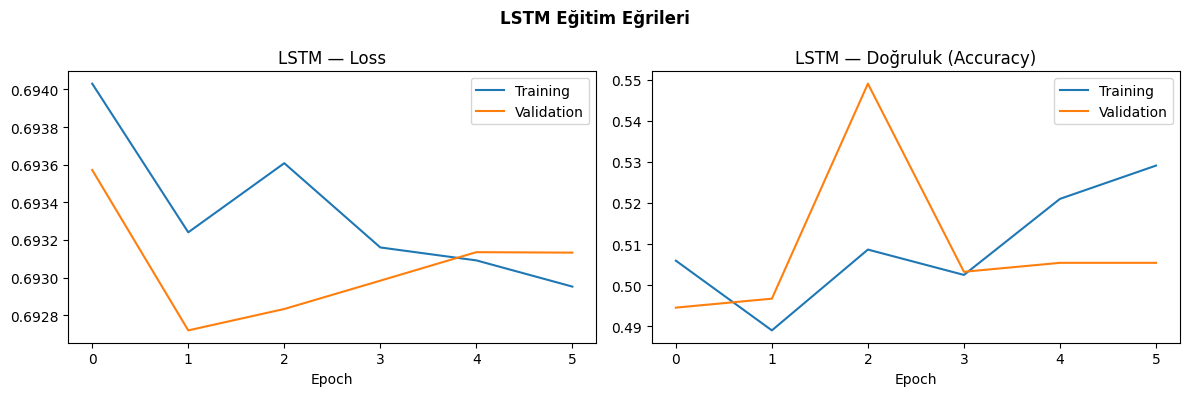

In [33]:
# ── EĞİTİM EĞRİLERİ ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Training')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('LSTM — Loss')
ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='Training')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('LSTM — Doğruluk (Accuracy)')
ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('LSTM Eğitim Eğrileri', fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Değerlendirme Metrikleri

| Metrik | Açıklama |
|---|---|
| **Accuracy** | Toplam doğru tahmin / toplam tahmin |
| **Precision** | Yükseliş tahminlerinin kaçı gerçekten yükseliş? |
| **Recall** | Gerçekte yükseliş olan günlerin kaçını yakaladı? |
| **F1 Score** | Precision & Recall harmonik ortalaması |
| **Confusion Matrix** | Doğru/yanlış tahminlerin dağılımı |
| **ROC-AUC** | Ayırt etme gücü: 0.5 = rastgele, 1.0 = mükemmel |

In [34]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── TAHMİN ───────────────────────────────────────────────────────────────────
y_prob = model.predict(X_test_seq, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# ── METRİKLER ────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test_seq, y_pred)
prec = precision_score(y_test_seq, y_pred, zero_division=0)
rec  = recall_score(y_test_seq, y_pred, zero_division=0)
f1   = f1_score(y_test_seq, y_pred, zero_division=0)
auc  = roc_auc_score(y_test_seq, y_prob)

print("=" * 50)
print("       LSTM DEĞERLENDİRME SONUÇLARI")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 50)

       LSTM DEĞERLENDİRME SONUÇLARI
  Accuracy  : 0.4860
  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
  ROC-AUC   : 0.5054


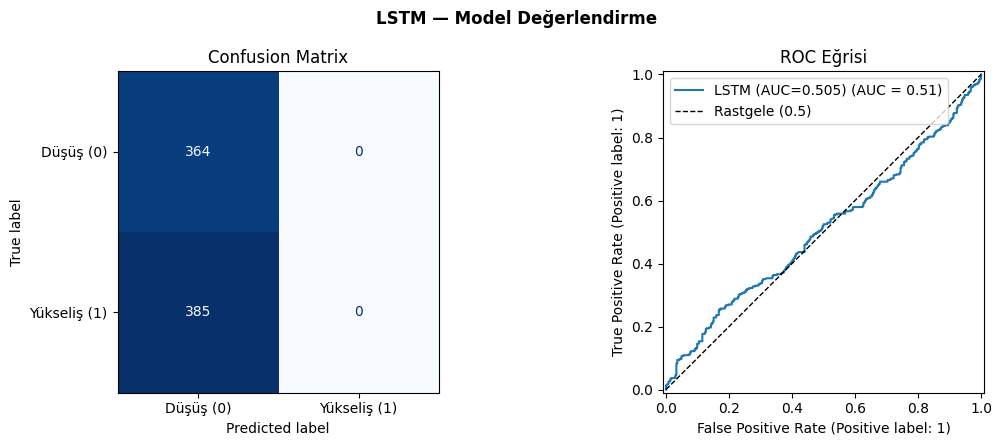

In [35]:
# ── CONFUSION MATRIX & ROC EĞRİSİ ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Düşüş (0)', 'Yükseliş (1)']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix')

# ROC Eğrisi
RocCurveDisplay.from_predictions(
    y_test_seq, y_prob, ax=ax2,
    name=f'LSTM (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele (0.5)')
ax2.set_title('ROC Eğrisi')
ax2.legend()

plt.suptitle('LSTM — Model Değerlendirme', fontweight='bold')
plt.tight_layout()
plt.show()

### 4d. Eğitim Log Kaydı

Her eğitim çalıştırıldığında aşağıdaki bilgiler `logs/` klasörüne otomatik kaydedilir:
- **Model mimarisi** (katmanlar, parametre sayıları)
- **Hiperparametreler** (WINDOW, epochs, batch_size, learning_rate, patience vb.)
- **Değerlendirme metrikleri** (Accuracy, Precision, Recall, F1, AUC)
- **Confusion Matrix** görüntüsü (PNG)
- **Loss & Accuracy eğrileri** görüntüsü (PNG)

In [36]:
import os, json
from datetime import datetime

# ── LOG KLASÖRÜ OLUŞTUR ──────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = os.path.join("logs", timestamp)
os.makedirs(log_dir, exist_ok=True)

# ── 1) MODEL MİMARİSİ ───────────────────────────────────────────────────────
summary_lines = []
model.summary(print_fn=lambda x: summary_lines.append(x))
model_summary = "\n".join(summary_lines)

with open(os.path.join(log_dir, "model_summary.txt"), "w", encoding="utf-8") as f:
    f.write(model_summary)

# ── 2) HİPERPARAMETRELER ────────────────────────────────────────────────────

with open(os.path.join(log_dir, "hyperparameters.json"), "w", encoding="utf-8") as f:
    json.dump(hyperparams, f, indent=2, ensure_ascii=False)

# ── 3) DEĞERLENDİRME METRİKLERİ ────────────────────────────────────────────
metrics = {
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(auc, 4),
}

with open(os.path.join(log_dir, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

# ── 4) LOSS & ACCURACY EĞRİLERİ → PNG ───────────────────────────────────────
fig_curves, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Training')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('LSTM — Loss')
ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='Training')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('LSTM — Doğruluk (Accuracy)')
ax2.set_xlabel('Epoch'); ax2.legend()

fig_curves.suptitle('LSTM Eğitim Eğrileri', fontweight='bold')
fig_curves.tight_layout()
fig_curves.savefig(os.path.join(log_dir, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.close(fig_curves)

# ── 5) CONFUSION MATRIX → PNG ───────────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Düşüş (0)', 'Yükseliş (1)']).plot(
    ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title('Confusion Matrix')
fig_cm.tight_layout()
fig_cm.savefig(os.path.join(log_dir, "confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.close(fig_cm)

# ── ÖZET ─────────────────────────────────────────────────────────────────────
print(f"✅ Log kaydı tamamlandı → {log_dir}/")
print(f"   ├── model_summary.txt")
print(f"   ├── hyperparameters.json")
print(f"   ├── metrics.json")
print(f"   ├── training_curves.png")
print(f"   └── confusion_matrix.png")
print(f"\n📊 Metrikler: Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")

✅ Log kaydı tamamlandı → logs\20260420_180531/
   ├── model_summary.txt
   ├── hyperparameters.json
   ├── metrics.json
   ├── training_curves.png
   └── confusion_matrix.png

📊 Metrikler: Acc=0.4860 | F1=0.0000 | AUC=0.5054
